In [1]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import json
import numpy as np
# import sys; sys.path.append("../src/")


In [2]:
dataset_name = "imagenet_2_per_class"
model_name = "vit"

In [3]:
use_cache = True # Set to false if you wanna do it from scratch
cache_dir = Path("../scripts/_cache")

In [4]:
prefix = ""

In [5]:
radii = [0, 1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 147]
print(len(radii))

17


## Soft stability rates for different explanations

In [6]:
lime_stability_rates_file = cache_dir / f"{model_name}_{dataset_name}_lime_soft_stability_rates.json"
shap_stability_rates_file = cache_dir / f"{model_name}_{dataset_name}_shap_soft_stability_rates.json"
intgrad_stability_rates_file = cache_dir / f"{model_name}_{dataset_name}_intgrad_soft_stability_rates.json"
mfaba_stability_rates_file = cache_dir / f"{model_name}_{dataset_name}_mfaba_soft_stability_rates.json"
random_stability_rates_file = cache_dir / f"{model_name}_{dataset_name}_random_soft_stability_rates.json"

In [7]:
def prepend_ones(curves):
    ones = np.ones((curves.shape[0], 1))
    return np.hstack((ones, curves))

In [8]:
if lime_stability_rates_file.exists() and use_cache:
    print("Loading LIME soft stability rates")
    with open(lime_stability_rates_file, 'r') as f:
        lime_stability_rates_dict = json.load(f)
        lime_stability_rates = prepend_ones(np.array(lime_stability_rates_dict['soft_stability_rates']))

Loading LIME soft stability rates


In [9]:
if shap_stability_rates_file.exists() and use_cache:
    print("Loading SHAP soft stability rates")
    with open(shap_stability_rates_file, 'r') as f:
        shap_stability_rates_dict = json.load(f)
        shap_stability_rates = prepend_ones(np.array(shap_stability_rates_dict['soft_stability_rates']))

Loading SHAP soft stability rates


In [10]:
if intgrad_stability_rates_file.exists() and use_cache:
    print("Loading IntGrad soft stability rates")
    with open(intgrad_stability_rates_file, 'r') as f:
        intgrad_stability_rates_dict = json.load(f)
        intgrad_stability_rates = prepend_ones(np.array(intgrad_stability_rates_dict['soft_stability_rates']))

Loading IntGrad soft stability rates


In [11]:
if mfaba_stability_rates_file.exists() and use_cache:
    print("Loading MFABA soft stability rates")
    with open(mfaba_stability_rates_file, 'r') as f:
        mfaba_stability_rates_dict = json.load(f)
        mfaba_stability_rates = prepend_ones(np.array(mfaba_stability_rates_dict['soft_stability_rates']))

Loading MFABA soft stability rates


In [12]:
if random_stability_rates_file.exists() and use_cache:
    print("Loading Random soft stability rates")
    with open(random_stability_rates_file, 'r') as f:
        random_stability_rates_dict = json.load(f)
        random_stability_rates = prepend_ones(np.array(random_stability_rates_dict['soft_stability_rates']))

Loading Random soft stability rates


In [13]:
def bootstrap_mean_and_ci(data, n_bootstrap=1000, ci=95):
    """Bootstraps mean and confidence interval across axis 0"""
    n_samples = data.shape[0]
    boot_means = np.empty((n_bootstrap, data.shape[1]))

    for i in range(n_bootstrap):
        sample_indices = np.random.choice(n_samples, size=n_samples, replace=True)
        boot_sample = data[sample_indices]
        boot_means[i] = boot_sample.mean(axis=0)

    lower_bound = np.percentile(boot_means, (100 - ci) / 2, axis=0)
    upper_bound = np.percentile(boot_means, 100 - (100 - ci) / 2, axis=0)
    mean_curve = boot_means.mean(axis=0)
    return mean_curve, lower_bound, upper_bound

<Figure size 640x480 with 0 Axes>

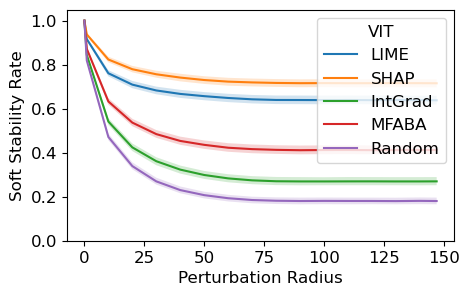

In [28]:
plt.clf()
plt.rcParams["font.family"] = "DejaVu Sans"
fs = 12
fig, ax = plt.subplots(figsize=(5,3))

mean, lb, ub = bootstrap_mean_and_ci(lime_stability_rates)
ax.plot(radii, mean, label="LIME")
ax.fill_between(radii, lb, ub, alpha=0.2)

mean, lb, ub = bootstrap_mean_and_ci(shap_stability_rates)
ax.plot(radii, mean, label="SHAP")
ax.fill_between(radii, lb, ub, alpha=0.2)

mean, lb, ub = bootstrap_mean_and_ci(intgrad_stability_rates)
ax.plot(radii, mean, label="IntGrad")
ax.fill_between(radii, lb, ub, alpha=0.2)

mean, lb, ub = bootstrap_mean_and_ci(mfaba_stability_rates)
ax.plot(radii, mean, label="MFABA")
ax.fill_between(radii, lb, ub, alpha=0.2)

mean, lb, ub = bootstrap_mean_and_ci(random_stability_rates)
ax.plot(radii, mean, label="Random")
ax.fill_between(radii, lb, ub, alpha=0.2)

ax.set_xlabel("Perturbation Radius", fontsize=fs)
ax.set_ylabel("Soft Stability Rate", fontsize=fs)
ax.tick_params(axis="both", labelsize=fs)
ax.set_ylim(0.0, 1.05)

ax.legend(title="VIT", loc="upper right", title_fontsize=fs, fontsize=fs)
fig.savefig(f'_dump/{model_name}_{dataset_name}_soft.pdf', bbox_inches="tight")
# plt.show()

## As a comparison, here are the certified radii when old-MuS uses lambda=0.25

In [15]:
lime_hard_stability_radii_file = cache_dir / f"{model_name}_{dataset_name}_lime_hard_stability_radii.json"
shap_hard_stability_radii_file = cache_dir / f"{model_name}_{dataset_name}_shap_hard_stability_radii.json"
intgrad_hard_stability_radii_file = cache_dir / f"{model_name}_{dataset_name}_intgrad_hard_stability_radii.json"
mfaba_hard_stability_radii_file = cache_dir / f"{model_name}_{dataset_name}_mfaba_hard_stability_radii.json"
random_hard_stability_radii_file = cache_dir / f"{model_name}_{dataset_name}_random_hard_stability_radii.json"

In [16]:
with open(lime_hard_stability_radii_file, 'r') as f:
    cert_rs_lime_dict = json.load(f)
    cert_rs_lime = torch.tensor(cert_rs_lime_dict['lambda_to_radii']['0.250'])
    
with open(shap_hard_stability_radii_file, 'r') as f:
    cert_rs_shap_dict = json.load(f)
    cert_rs_shap = torch.tensor(cert_rs_shap_dict['lambda_to_radii']['0.250'])

with open(intgrad_hard_stability_radii_file, 'r') as f:
    cert_rs_intgrad_dict = json.load(f)
    cert_rs_intgrad = torch.tensor(cert_rs_intgrad_dict['lambda_to_radii']['0.250'])
    
with open(mfaba_hard_stability_radii_file, 'r') as f:
    cert_rs_mfaba_dict = json.load(f)
    cert_rs_mfaba = torch.tensor(cert_rs_mfaba_dict['lambda_to_radii']['0.250'])
    
with open(random_hard_stability_radii_file, 'r') as f:
    cert_rs_random_dict = json.load(f)
    cert_rs_random = torch.tensor(cert_rs_random_dict['lambda_to_radii']['0.250'])
    

In [17]:
r_max = 2.0
num_samples = cert_rs_lime.size(0)
r_ticks = torch.arange(start=0.0, end=2.0, step=0.001)

cert_stability_rates_lime = torch.tensor([(cert_rs_lime >= rt).sum() / num_samples for rt in r_ticks])
cert_stability_rates_shap = torch.tensor([(cert_rs_shap >= rt).sum() / num_samples for rt in r_ticks])
cert_stability_rates_intgrad = torch.tensor([(cert_rs_intgrad >= rt).sum() / num_samples for rt in r_ticks])
cert_stability_rates_mfaba = torch.tensor([(cert_rs_mfaba >= rt).sum() / num_samples for rt in r_ticks])
cert_stability_rates_random = torch.tensor([(cert_rs_random >= rt).sum() / num_samples for rt in r_ticks])

<Figure size 640x480 with 0 Axes>

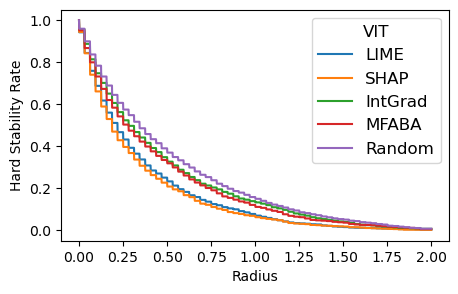

In [30]:
plt.clf()
plt.rcParams["font.family"] = "DejaVu Sans"

plt.figure(figsize=(5,3))
plt.plot(r_ticks.numpy(), cert_stability_rates_lime, label="LIME")
plt.plot(r_ticks.numpy(), cert_stability_rates_shap, label="SHAP")
plt.plot(r_ticks.numpy(), cert_stability_rates_intgrad, label="IntGrad")
plt.plot(r_ticks.numpy(), cert_stability_rates_mfaba, label="MFABA")
plt.plot(r_ticks.numpy(), cert_stability_rates_random, label="Random")


plt.ylim([-0.05,1.05])
plt.xlabel('Radius')
plt.ylabel('Hard Stability Rate')
plt.legend(title="VIT", loc="upper right", title_fontsize=fs, fontsize=fs)
plt.savefig(f'_dump/{model_name}_{dataset_name}_hard.pdf', bbox_inches="tight")
plt.show()


## Combine soft and hard stability in the same plot

In [19]:
# plt.clf()
# plt.figure(figsize=(6, 4))
# plt.plot(all_radius, lime_stability_rates.cpu().mean(dim=0).numpy(), label="LIME Soft")
# plt.plot(all_radius, shap_stability_rates.cpu().mean(dim=0).numpy(), label="SHAP Soft")
# plt.plot(all_radius, intgrad_stability_rates.cpu().mean(dim=0).numpy(), label="IntGrad Soft")
# plt.plot(all_radius, mfaba_stability_rates.cpu().mean(dim=0).numpy(), label="MFABA Soft")

# plt.plot(cert_lime_stability_rates.sort(descending=True).values, [0.001 * i for i in range(0, len(images))], label="LIME Hard", color="#1f77b4")
# plt.plot(cert_shap_stability_rates.sort(descending=True).values, [0.001 * i for i in range(0, len(images))], label="SHAP Hard", color="#ff7f0e")
# plt.plot(cert_intgrad_stability_rates.sort(descending=True).values, [0.001 * i for i in range(0, len(images))], label="IntGrad Hard", color="#2ca02c")
# plt.plot(cert_mfaba_stability_rates.sort(descending=True).values, [0.001 * i for i in range(0, len(images))], label="MFABA Hard", color="#d62728")
# plt.xlabel('Radius')
# plt.ylabel('Stability Rate')
# plt.legend(title="ViT", loc="upper right", prop={'size': 7})
# plt.title('Soft vs. Hard Stability')
# plt.savefig('_dump/vit_imagenet_softvhard_1k', bbox_inches="tight")
